# HW5: Word-level Language Model on a Larger Turgenev Corpus

В этом ноутбуке word-level language model обучается уже не на одном тексте,
а на объединённом корпусе нескольких произведений И.С. Тургенева.
Код также подготовлен к более тяжёлому обучению на GPU: увеличены размеры модели,
добавлены `AMP`, `pin_memory`, несколько `DataLoader` workers и более крупные батчи для `cuda`.

## План

1. Загружаем несколько произведений и собираем единый корпус.
2. Токенизируем текст на уровне слов.
3. Строим более крупный словарь и датасет для language modeling.
4. Готовим GPU-friendly конфигурацию обучения.
5. Обучаем `RNN` и `LSTM`.
6. Строим график `training loss` и сравниваем генерацию.

In [1]:
import math
import os
import random
import re
from collections import Counter
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
from bs4 import BeautifulSoup
from pymorphy3 import MorphAnalyzer
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = device.type == "cuda"
morph = MorphAnalyzer()

print("Device:", device)
print("AMP enabled:", USE_AMP)

Device: cuda
AMP enabled: True


In [ ]:
CORPUS_SOURCES = [
    {
        "title": "Отцы и дети",
        "url": "http://az.lib.ru/t/turgenew_i_s/text_0040.shtml",
    },
    {
        "title": "Первая любовь",
        "url": "http://az.lib.ru/t/turgenew_i_s/text_0120.shtml",
    },
    {
        "title": "Дым",
        "url": "http://az.lib.ru/t/turgenew_i_s/text_0280.shtml",
    },
    {
        "title": "Жид",
        "url": "http://az.lib.ru/t/turgenew_i_s/text_0048.shtml",
    },
    {
        "title": "Муму",
        "url": "http://az.lib.ru/t/turgenew_i_s/text_0070.shtml",
    },
]

CACHE_DIR = Path("hw5/.corpus_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

REQUEST_HEADERS = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36"
}

ALLOWED_PUNCT = ".,;:!?«»-—"


def extract_main_text(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")
    text = soup.get_text("\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    start_candidates = [
        idx
        for idx, line in enumerate(lines)
        if line == "Иван Сергеевич Тургенев"
    ]
    start = start_candidates[0] if start_candidates else 0

    footer_idx = None
    for idx in range(len(lines) - 1, start, -1):
        if lines[idx].startswith("Комментарии:") or lines[idx].startswith(
            "Связаться с программистом сайта"
        ):
            footer_idx = idx
            break

    body_lines = lines[start:footer_idx] if footer_idx is not None else lines[start:]
    body = "\n".join(body_lines)
    body = re.sub(r"\{[^{}]*\}", " ", body)
    body = re.sub(r"\s+", " ", body)
    return body.lower()


def keep_only_russian_and_punctuation(text: str) -> str:
    text = text.lower().replace("...", "…")
    text = re.sub(fr"[^а-яё\s{re.escape(ALLOWED_PUNCT)}…-]", " ", text)
    text = re.sub(r"-{2,}", " — ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def load_corpus(sources: list[dict]) -> tuple[str, list[dict], list[dict]]:
    documents = []
    loaded_meta = []

    for item in sources:
        url = item["url"]
        title = item["title"]
        cache_path = CACHE_DIR / f"{title.replace(' ', '_').lower()}.txt"

        if cache_path.exists():
            text = cache_path.read_text(encoding="utf-8")
        else:
            response = requests.get(url, headers=REQUEST_HEADERS, timeout=60)
            response.raise_for_status()
            text = extract_main_text(response.text)
            cache_path.write_text(text, encoding="utf-8")

        cleaned_text = keep_only_russian_and_punctuation(text)
        documents.append({"title": title, "text": cleaned_text})
        loaded_meta.append(
            {
                "title": title,
                "url": url,
                "characters": len(cleaned_text),
            }
        )

    full_text = "\n\n".join(document["text"] for document in documents)
    return full_text, loaded_meta, documents


text, corpus_meta, documents = load_corpus(CORPUS_SOURCES)
corpus_df = pd.DataFrame(corpus_meta)
corpus_df

,title,url,characters
0,Отцы и дети,http://az.lib.ru/t/turgenew_i_s/text_0040.shtml,352278
1,Первая любовь,http://az.lib.ru/t/turgenew_i_s/text_0120.shtml,117575
2,Дым,http://az.lib.ru/t/turgenew_i_s/text_0280.shtml,315102
3,Жид,http://az.lib.ru/t/turgenew_i_s/text_0048.shtml,28267
4,Муму,http://az.lib.ru/t/turgenew_i_s/text_0070.shtml,53655


In [3]:
WORD_RE = re.compile(r"[а-яё]+(?:-[а-яё]+)*", flags=re.IGNORECASE)
PUNCT_RE = re.compile(r"[.,;:!?()«»…—-]")
TOKEN_RE = re.compile(r"[а-яё]+(?:-[а-яё]+)*|[.,;:!?()«»…—-]", flags=re.IGNORECASE)


@lru_cache(maxsize=200_000)
def lemmatize_token(token: str) -> str:
    if not WORD_RE.fullmatch(token):
        return token
    return morph.parse(token)[0].normal_form


def tokenize(text: str, lemmatize: bool = True) -> list[str]:
    raw_tokens = TOKEN_RE.findall(text)
    if not lemmatize:
        return raw_tokens
    return [lemmatize_token(token) for token in raw_tokens]


def detokenize(tokens: list[str]) -> str:
    text = " ".join(tokens)
    text = re.sub(r"\s+([,.;:!?…])", r"\1", text)
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s+\)", ")", text)
    text = text.replace("« ", "«").replace(" »", "»")
    text = text.replace(" — ", " — ")
    text = text.replace(" - ", "-")
    return text


raw_tokens = tokenize(text, lemmatize=False)
tokens = tokenize(text, lemmatize=False)

invalid_raw_tokens = [
    token for token in raw_tokens if not (WORD_RE.fullmatch(token) or PUNCT_RE.fullmatch(token))
]
latin_tokens = [token for token in raw_tokens if re.search(r"[a-z]", token, flags=re.IGNORECASE)]

print("First 40 raw tokens:", raw_tokens[:40])
print("First 40 lemmatized tokens:", tokens[:40])
print("Number of tokens:", len(tokens))
print("Unique raw tokens:", len(set(raw_tokens)))
print("Unique lemmatized tokens:", len(set(tokens)))
print("Invalid raw tokens found:", len(invalid_raw_tokens))
print("Latin tokens found:", len(latin_tokens))

First 40 raw tokens: ['иван', 'сергеевич', 'тургенев', '.', 'отцы', 'и', 'дети', 'роман', 'книга', ':', 'и', '.', 'с', '.', 'тургенев', '.', 'накануне', '.', 'отцы', 'и', 'дети', 'издательство', 'художественная', 'литература', ',', 'москва', ',', ':', '.', ',', 'декабря', 'посвящается', 'памяти', 'виссариона', 'григорьевича', 'белинского', '—', 'что', ',', 'петр']
First 40 lemmatized tokens: ['иван', 'сергеевич', 'тургенев', '.', 'отцы', 'и', 'дети', 'роман', 'книга', ':', 'и', '.', 'с', '.', 'тургенев', '.', 'накануне', '.', 'отцы', 'и', 'дети', 'издательство', 'художественная', 'литература', ',', 'москва', ',', ':', '.', ',', 'декабря', 'посвящается', 'памяти', 'виссариона', 'григорьевича', 'белинского', '—', 'что', ',', 'петр']
Number of tokens: 174393
Unique raw tokens: 24934
Unique lemmatized tokens: 24934
Invalid raw tokens found: 0
Latin tokens found: 0


In [4]:
MAX_VOCAB = 12_000
SEQ_LEN = 32
BATCH_SIZE = 128
EMB_DIM = 1024
HIDDEN_DIM = 2048
NUM_LAYERS = 10
DROPOUT = 0.1
EPOCHS = 5
LR = 1e-3
TRAIN_FRAC = 0.8
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = device.type == "cuda"
GRAD_CLIP = 1.0

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)

itos = ["<pad>", "<unk>"] + [token for token, _ in most_common]
stoi = {token: idx for idx, token in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]
ids = [stoi.get(token, UNK_ID) for token in tokens]

print("Using tokens:", len(tokens))
print("Vocabulary size:", len(itos))
print("UNK count:", sum(token_id == UNK_ID for token_id in ids))
print("Batch size:", BATCH_SIZE)
print("Embedding dim:", EMB_DIM)
print("Hidden dim:", HIDDEN_DIM)
print("Num layers:", NUM_LAYERS)

Using tokens: 174393
Vocabulary size: 12000
UNK count: 12936
Batch size: 128
Embedding dim: 1024
Hidden dim: 2048
Num layers: 10


In [5]:
class LanguageModelingDataset(Dataset):
    def __init__(self, segments: list[list[int]], seq_len: int):
        self.segments = segments
        self.seq_len = seq_len
        self.examples = []

        for segment_idx, segment in enumerate(self.segments):
            for start_idx in range(len(segment) - self.seq_len):
                self.examples.append((segment_idx, start_idx))

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, idx: int):
        segment_idx, start_idx = self.examples[idx]
        segment = self.segments[segment_idx]

        x = torch.tensor(
            segment[start_idx : start_idx + self.seq_len],
            dtype=torch.long,
        )
        y = torch.tensor(
            segment[start_idx + 1 : start_idx + self.seq_len + 1],
            dtype=torch.long,
        )
        return x, y


def build_document_splits(
    documents: list[dict],
    train_frac: float,
    seq_len: int,
    stoi: dict[str, int],
    unk_id: int,
):
    train_segments = []
    test_segments = []
    split_rows = []
    gap = seq_len

    for document in documents:
        doc_tokens = tokenize(document["text"])
        doc_ids = [stoi.get(token, unk_id) for token in doc_tokens]

        min_test_tokens = max(seq_len * 2, 256)
        tentative_test_size = max(int(len(doc_ids) * (1 - train_frac)), min_test_tokens)
        tentative_test_size = min(tentative_test_size, len(doc_ids) - seq_len - 1)

        if tentative_test_size <= seq_len:
            train_segments.append(doc_ids)
            split_rows.append(
                {
                    "title": document["title"],
                    "total_tokens": len(doc_ids),
                    "train_tokens": len(doc_ids),
                    "test_tokens": 0,
                    "gap_tokens": 0,
                }
            )
            continue

        train_end = len(doc_ids) - tentative_test_size - gap
        train_end = max(train_end, seq_len + 1)

        train_part = doc_ids[:train_end]
        test_start = min(train_end + gap, len(doc_ids) - seq_len - 1)
        test_part = doc_ids[test_start:]

        if len(test_part) <= seq_len:
            train_part = doc_ids
            test_part = []
            effective_gap = 0
        else:
            effective_gap = test_start - train_end

        train_segments.append(train_part)
        if test_part:
            test_segments.append(test_part)

        split_rows.append(
            {
                "title": document["title"],
                "total_tokens": len(doc_ids),
                "train_tokens": len(train_part),
                "test_tokens": len(test_part),
                "gap_tokens": effective_gap,
            }
        )

    return train_segments, test_segments, pd.DataFrame(split_rows)


train_segments, test_segments, split_df = build_document_splits(
    documents=documents,
    train_frac=TRAIN_FRAC,
    seq_len=SEQ_LEN,
    stoi=stoi,
    unk_id=UNK_ID,
)

train_dataset = LanguageModelingDataset(train_segments, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_segments, SEQ_LEN)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print("Train segments:", len(train_segments))
print("Test segments:", len(test_segments))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

split_df

Train segments: 5
Test segments: 5
Train examples: 139197
Test examples: 34716


,title,total_tokens,train_tokens,test_tokens,gap_tokens
0,Отцы и дети,70867,56662,14173,32
1,Первая любовь,24078,19231,4815,32
2,Дым,62883,50275,12576,32
3,Жид,5894,4684,1178,32
4,Муму,10671,8505,2134,32


## Модели

Реализуем две версии:

- `WordRNN` на базе `nn.RNN`
- `WordLSTM` на базе `nn.LSTM`


In [6]:
class WordRNN(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        hidden, state = self.rnn(x, state)
        logits = self.out(hidden)
        return logits, state


class WordLSTM(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        emb_dim: int,
        hidden_dim: int,
        num_layers: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        hidden, state = self.lstm(x, state)
        logits = self.out(hidden)
        return logits, state

In [7]:
criterion = nn.CrossEntropyLoss()


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=PIN_MEMORY)
        yb = yb.to(device, non_blocking=PIN_MEMORY)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            logits, _ = model(xb)
            loss = criterion(logits.reshape(-1, len(itos)), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    perplexity = math.exp(mean_loss)
    return mean_loss, perplexity


def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LR):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = {
        "train_losses": [],
        "test_losses": [],
        "train_ppls": [],
        "test_ppls": [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=PIN_MEMORY)
            yb = yb.to(device, non_blocking=PIN_MEMORY)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                logits, _ = model(xb)
                loss = criterion(logits.reshape(-1, len(itos)), yb.reshape(-1))

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_ppl = math.exp(train_loss)
        test_loss, test_ppl = evaluate(model, test_loader)

        history["train_losses"].append(train_loss)
        history["test_losses"].append(test_loss)
        history["train_ppls"].append(train_ppl)
        history["test_ppls"].append(test_ppl)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
            f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
        )

    return history

In [8]:
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.empty_cache()

rnn_model = WordRNN(
    len(itos),
    EMB_DIM,
    HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)
print(f"Training RNN on {len(tokens):,} tokens from {len(CORPUS_SOURCES)} texts")
rnn_history = train_model(rnn_model, train_loader, test_loader)

torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.empty_cache()

lstm_model = WordLSTM(
    len(itos),
    EMB_DIM,
    HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)
print("\nTraining LSTM")
lstm_history = train_model(lstm_model, train_loader, test_loader)

Training RNN on 174,393 tokens from 5 texts
Epoch 1/5 | train loss = 7.0850 | train ppl = 1193.95 | test loss = 6.2631 | test ppl = 524.84
Epoch 2/5 | train loss = 5.9959 | train ppl = 401.76 | test loss = 5.3885 | test ppl = 218.87
Epoch 3/5 | train loss = 5.2685 | train ppl = 194.13 | test loss = 5.3498 | test ppl = 210.56
Epoch 4/5 | train loss = 5.2584 | train ppl = 192.17 | test loss = 5.2997 | test ppl = 200.28
Epoch 5/5 | train loss = 5.2500 | train ppl = 190.57 | test loss = 5.3728 | test ppl = 215.46

Training LSTM
Epoch 1/5 | train loss = 5.0906 | train ppl = 162.48 | test loss = 5.1600 | test ppl = 174.16
Epoch 2/5 | train loss = 5.0716 | train ppl = 159.44 | test loss = 5.1632 | test ppl = 174.72
Epoch 3/5 | train loss = 5.0710 | train ppl = 159.34 | test loss = 5.1553 | test ppl = 173.35
Epoch 4/5 | train loss = 5.0641 | train ppl = 158.23 | test loss = 5.1553 | test ppl = 173.35
Epoch 5/5 | train loss = 5.0611 | train ppl = 157.77 | test loss = 5.1519 | test ppl = 172.76


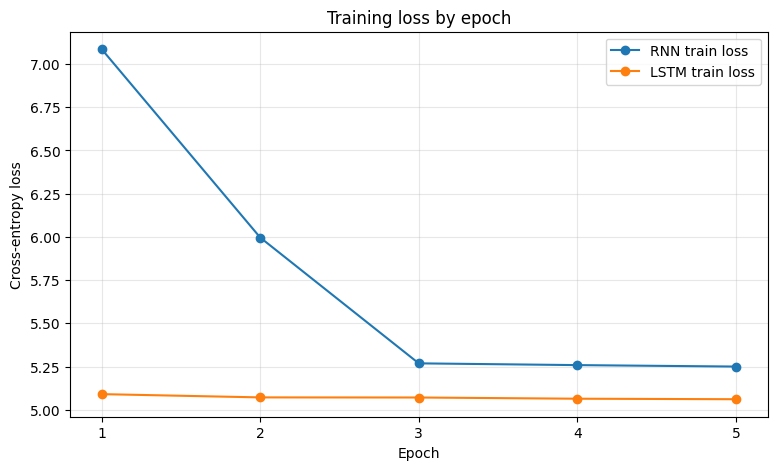

In [9]:
epochs = np.arange(1, EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, rnn_history["train_losses"], marker="o", label="RNN train loss")
plt.plot(epochs, lstm_history["train_losses"], marker="o", label="LSTM train loss")
plt.title("Training loss by epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.xticks(epochs)
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [10]:
def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    logits = logits / max(temperature, 1e-5)

    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        sampled_idx = torch.multinomial(probs, num_samples=1).item()
        return int(indices[sampled_idx].item())

    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())


@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=35,
    method="greedy",
    temperature=1.0,
    top_k=None,
):
    model.eval()

    prompt_tokens = tokenize(prompt.lower())
    if not prompt_tokens:
        raise ValueError("Prompt is empty after tokenization.")

    generated_ids = [stoi.get(token, UNK_ID) for token in prompt_tokens]
    x = torch.tensor([generated_ids], dtype=torch.long, device=device)
    logits, state = model(x)
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k,
        )
        generated_ids.append(next_id)
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, state = model(x_next, state)
        next_logits = logits[0, -1]

    return detokenize([itos[idx] for idx in generated_ids])


In [11]:
prompt = "николай петрович"

rnn_generations = {
    "greedy": generate_text(rnn_model, prompt, method="greedy"),
    "sampling": generate_text(rnn_model, prompt, method="sampling"),
    "sampling_temperature_0.7": generate_text(
        rnn_model,
        prompt,
        method="sampling",
        temperature=0.7,
    ),
    "sampling_top_k_10": generate_text(
        rnn_model,
        prompt,
        method="sampling",
        temperature=0.9,
        top_k=10,
    ),
}

for mode, generated_text in rnn_generations.items():
    print(f"RNN | {mode}")
    print(generated_text)
    print()


RNN | greedy
николай петрович <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

RNN | sampling
николай петрович, быть, — до прусский., людской… не в аркадий с губа сомневаться. на —,, — и, шляпа. князь — в и что, часть и кожица

RNN | sampling_temperature_0.7
николай петрович <unk> он. мужчина,, <unk>,. <unk> <unk> и, позволить себя <unk>, на, я, они <unk> <unk>? <unk> <unk>?,.,, тот <unk> богач

RNN | sampling_top_k_10
николай петрович <unk> он. я,,,. он, <unk> <unk> <unk> <unk> и <unk> <unk> <unk> с и <unk>, он <unk>, <unk> я <unk> <unk> <unk> <unk> в и, на



In [12]:
lstm_generations = {
    "greedy": generate_text(lstm_model, prompt, method="greedy"),
    "sampling": generate_text(lstm_model, prompt, method="sampling"),
    "sampling_temperature_0.7": generate_text(
        lstm_model,
        prompt,
        method="sampling",
        temperature=0.7,
    ),
    "sampling_top_k_10": generate_text(
        lstm_model,
        prompt,
        method="sampling",
        temperature=0.9,
        top_k=10,
    ),
}

for mode, generated_text in lstm_generations.items():
    print(f"LSTM | {mode}")
    print(generated_text)
    print()


LSTM | greedy
николай петрович <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

LSTM | sampling
николай петрович он и к, восторг коренной петрович но, —. свой и в с, порывисто право видеть на она сергеевич. быть, девочка довольно барыня —? <unk> и они, всё

LSTM | sampling_temperature_0.7
николай петрович,, за? на он. и <unk>,. и <unk>,., <unk>?:, <unk> <unk> <unk> я. зато, который <unk> я <unk> <unk>. <unk>.

LSTM | sampling_top_k_10
николай петрович.. <unk> я <unk> <unk>, <unk> <unk> <unk> я <unk> <unk> она <unk> <unk>, — — <unk>, и <unk> <unk> <unk>,, <unk>,, она,,,,



In [13]:
comparison_df = pd.DataFrame(
    {
        "model": ["RNN", "LSTM"],
        "final_train_loss": [
            rnn_history["train_losses"][-1],
            lstm_history["train_losses"][-1],
        ],
        "best_test_loss": [
            min(rnn_history["test_losses"]),
            min(lstm_history["test_losses"]),
        ],
        "final_test_loss": [
            rnn_history["test_losses"][-1],
            lstm_history["test_losses"][-1],
        ],
        "best_test_ppl": [
            min(rnn_history["test_ppls"]),
            min(lstm_history["test_ppls"]),
        ],
    }
)

comparison_df.round(4)


,model,final_train_loss,best_test_loss,final_test_loss,best_test_ppl
0,RNN,5.2500,5.2997,5.3728,200.2812
1,LSTM,5.0611,5.1519,5.1519,172.7643


## Сравнение качества генерации

По примерам выше обычно видно следующее:

- `greedy`  быстро скатывается в повторы;
- `sampling` даёт больше разнообразия, но сильнее шумит и чаще приводит к неудачным словам или разрывам смысла;
- `sampling` с `temperature=0.7` уменьшает хаотичность по сравнению с обычным sampling и чаще выглядит связнее;
- `top-k` тоже часто скатыывается в повтор
